✅ Logistic Regression (manuel) entraînée
Accuracy Logistic Regression (manuel) : 0.6050
Accuracy Decision Tree : 0.9050


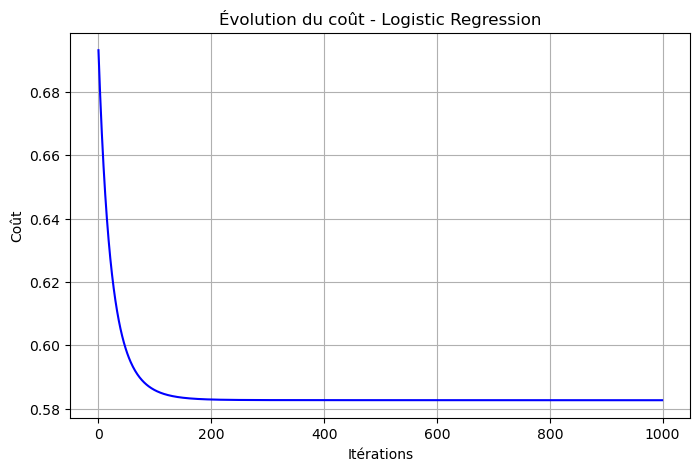

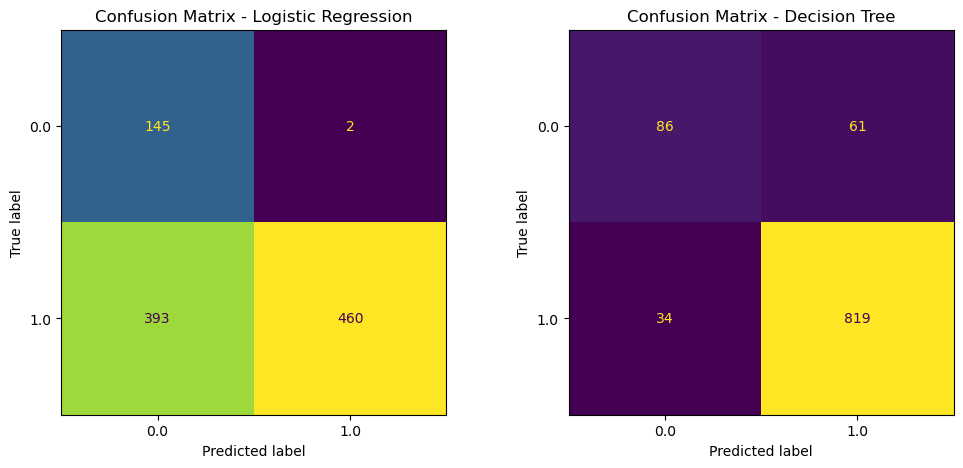

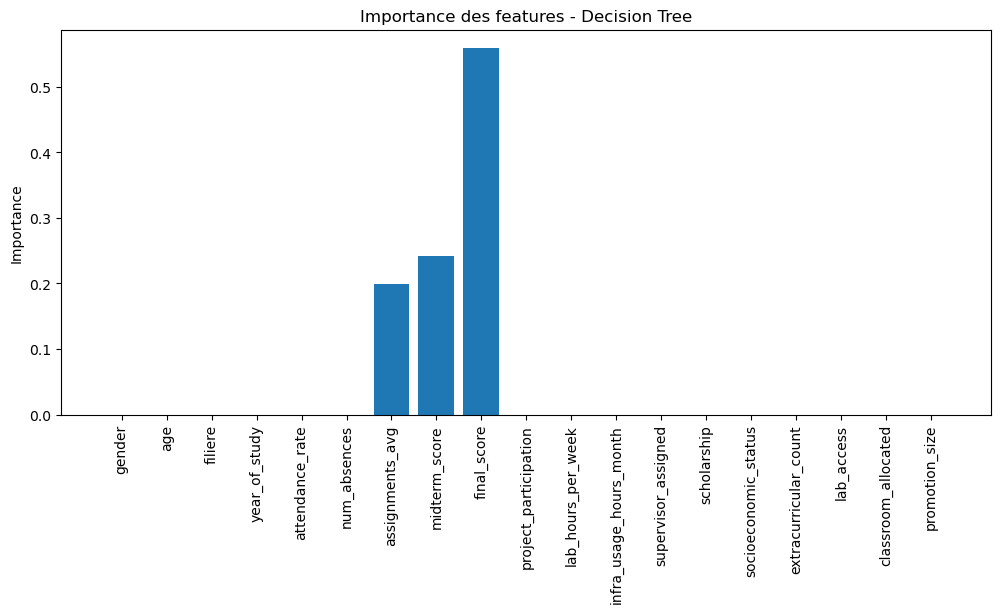

✅ Modèles sauvegardés pour API/Streamlit


AttributeError: 'LogisticRegressionManual' object has no attribute 'feature_importances_'

<Figure size 1200x500 with 0 Axes>

In [6]:
# -*- coding: utf-8 -*-
# =============================================
# Présentation Projet ENSPD - Prédiction Réussite Académique
# Script Python prêt à exécuter
# =============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier

# =============================================
# 1️⃣ Charger le dataset nettoyé
# =============================================
df = pd.read_csv("ensp_dataset_5000_clean.csv")

# Encoder les variables catégorielles
label_cols = ['gender', 'filiere', 'lab_access', 'classroom_allocated', 
              'scholarship', 'socioeconomic_status', 'supervisor_assigned']
for col in label_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# Séparer features et target
X = df.drop(columns=['passed', 'overall_grade', 'student_id'])
y = df['passed']

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# =============================================
# 2️⃣ Régression Logistique manuelle
# =============================================
class LogisticRegressionManual:
    def __init__(self, learning_rate=0.1, iterations=1000):
        self.lr = learning_rate
        self.iterations = iterations
        self.weights = None
        self.cost_history = []

    def sigmoid(self, z):
        z = np.clip(z, -500, 500)  # éviter overflow
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float)
        m, n = X.shape
        self.weights = np.zeros(n)
        for i in range(self.iterations):
            z = X @ self.weights
            y_pred = self.sigmoid(z)
            cost = -(1/m) * np.sum(y * np.log(y_pred + 1e-15) + (1-y)*np.log(1-y_pred + 1e-15))
            self.cost_history.append(cost)
            gradient = (1/m) * (X.T @ (y_pred - y))
            self.weights -= self.lr * gradient
        print("✅ Logistic Regression (manuel) entraînée")

    def predict_proba(self, X):
        return self.sigmoid(np.array(X, dtype=float) @ self.weights)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

# Entraînement
log_model = LogisticRegressionManual(learning_rate=0.1, iterations=1000)
log_model.fit(X_train, y_train)

# Prédiction et évaluation
y_pred_log = log_model.predict(X_test)
acc_log = accuracy_score(y_test, y_pred_log)
print(f"Accuracy Logistic Regression (manuel) : {acc_log:.4f}")

# =============================================
# 3️⃣ Arbre de décision
# =============================================
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)
acc_tree = accuracy_score(y_test, y_pred_tree)
print(f"Accuracy Decision Tree : {acc_tree:.4f}")

# =============================================
# 4️⃣ Visualisation
# =============================================
# Courbe coût Régression Logistique
plt.figure(figsize=(8,5))
plt.plot(log_model.cost_history, color='blue')
plt.title("Évolution du coût - Logistic Regression")
plt.xlabel("Itérations")
plt.ylabel("Coût")
plt.grid(True)
plt.show()

# Matrices de confusion
fig, axes = plt.subplots(1,2, figsize=(12,5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log, ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix - Logistic Regression")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree, ax=axes[1], colorbar=False)
axes[1].set_title("Confusion Matrix - Decision Tree")
plt.show()

# Importance des features Arbre de décision
plt.figure(figsize=(12,5))
plt.bar(range(len(tree_model.feature_importances_)), tree_model.feature_importances_)
plt.xticks(range(len(X.columns)), X.columns, rotation=90)
plt.ylabel("Importance")
plt.title("Importance des features - Decision Tree")
plt.show()

# =============================================
# 5️⃣ Sauvegarde des modèles pour API/Streamlit
# =============================================
with open("log_model_manual.pkl", "wb") as f:
    pickle.dump(log_model, f)
with open("tree_model.pkl", "wb") as f:
    pickle.dump(tree_model, f)
print("✅ Modèles sauvegardés pour API/Streamlit")

# Importance des features Arbre de décision
plt.figure(figsize=(12,5))
plt.bar(range(len(log_model.feature_importances_)), log_model.feature_importances_)
plt.xticks(range(len(X.columns)), X.columns, rotation=90)
plt.ylabel("Importance")
plt.title("Importance des features - Decision Tree")
plt.show()

# =============================================
# Fin du script de présentation
# =============================================
